In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
 
from utils import compute_zscore, generate_signals, backtest, sharpe_ratio
 
import warnings
warnings.filterwarnings("ignore")
 
plt.rcParams["figure.figsize"] = (12, 5)

In [2]:
# use same tickers as before
TICKER_A = "SAM"
TICKER_B = "BF-B"

START_DATE = "2022-01-01"
END_DATE = "2024-01-01"

data = yf.download([TICKER_A, TICKER_B], start=START_DATE, end=END_DATE, auto_adjust=True)["Close"]
data = data.dropna()

series_a = data[TICKER_A]
series_b = data[TICKER_B]


[*********************100%***********************]  2 of 2 completed


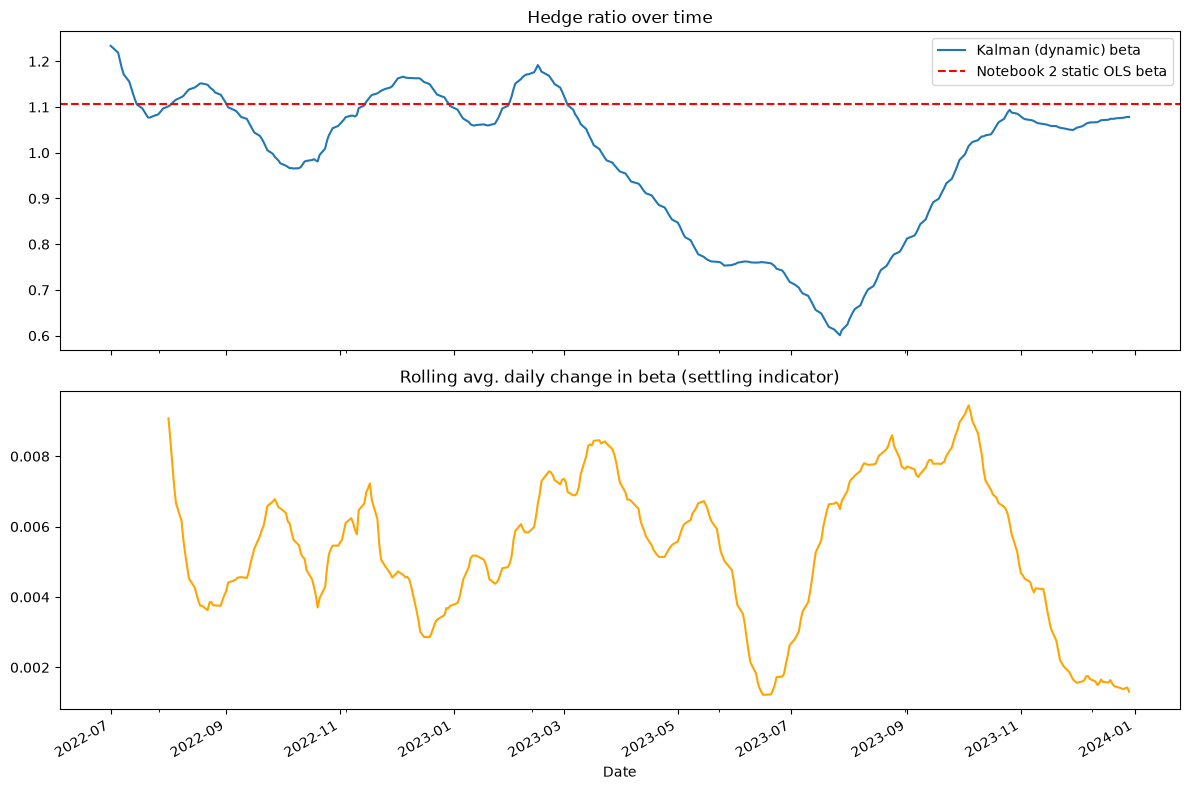

In [21]:
def kalman_filter_hedge_ratio(y: pd.Series, x: pd.Series, delta: float = 1e-4, obs_variance: float = 1.0, initial_state: np.ndarray = None) -> tuple:
    n = len(y)
    # states alpha, beta
    state = initial_state if initial_state is not None else np.array([0.0, 1.0])

    # state covariance p - used in kalman gain
    P = np.eye(2) * 1.0

    # process noise covariance q - used in predicting parameters alpha beta
    Q = delta / (1 - delta) * np.eye(2)

    # observation variance - determines how much value of asset daily is just market noise
    R = obs_variance

    alphas = np.zeros(n)
    betas = np.zeros(n)
    innovations = np.zeros(n)

    for t in range(n):

        # observation matrix - y = [1, x] * [alpha, beta] <-- measurement equation but without vt, as when calculating with
        # expected values, noise assumed symmetrical and about zero so goes to zero

        H = np.array([1.0, x.iloc[t]])

        # update p as it grows more uncertain
        p_predicted = P + Q

        # update and compute remaining variables
        y_pred = H @ state

        innovation = y.iloc[t] - y_pred

        # innovation variance 
        S = H @ p_predicted @ H.T + R # H.T here is transpose so works algebraically

        # kalman gain
        K = p_predicted @ H / S

        # updated state estimate
        state = state + K * innovation

        # updated co variance
        P = (np.eye(2) - np.outer(K, H)) @ p_predicted

        alphas[t] = state[0]
        betas[t] = state[1]
        innovations[t] = innovation

    return (
        pd.Series(alphas, index=y.index),
        pd.Series(betas, index=y.index),
        pd.Series(innovations, index=y.index),
    )

# check dynamic hedge ratio

model = sm.OLS(series_a, sm.add_constant(series_b)).fit()
obs_variance = model.resid.var()
initial_guess = np.array([model.params.iloc[0], model.params.iloc[1]]) # alpha and beta from OLS
alphas, betas, innovations = kalman_filter_hedge_ratio(series_a, series_b, delta=1e-4, obs_variance=obs_variance,initial_state=initial_guess )

BURN_IN_DATE = "2022-07-01"

alphas = alphas[alphas.index >= BURN_IN_DATE]
betas = betas[betas.index >= BURN_IN_DATE]
innovations = innovations[innovations.index >= BURN_IN_DATE]


STATIC_OLS_BETA = 1.1062

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

betas.plot(ax=axes[0], label="Kalman (dynamic) beta")
axes[0].axhline(STATIC_OLS_BETA, color="red", linestyle="--", label="Notebook 2 static OLS beta")
axes[0].legend()
axes[0].set_title("Hedge ratio over time")

betas.diff().abs().rolling(20).mean().plot(ax=axes[1], color="orange")
axes[1].set_title("Rolling avg. daily change in beta (settling indicator)")

plt.tight_layout()

In [22]:
# stats
spread = innovations
zscore = compute_zscore(spread, window=30)
positions = generate_signals(zscore, entry_threshold=2.0, exit_threshold=0.5)
daily_pnl = backtest(positions, spread)
cumulative_pnl = daily_pnl.cumsum()

sr = sharpe_ratio(daily_pnl.dropna())
print(f"Kalman-based Sharpe ({TICKER_A}/{TICKER_B}): {sr:.2f}")
print(f"Total P&L (spread units): {cumulative_pnl.iloc[-1]:.2f}")
print(f"Number of trades: {(positions.diff() != 0).sum()}")

Kalman-based Sharpe (SAM/BF-B): 1.77
Total P&L (spread units): 164.63
Number of trades: 21
